The goal is straightforward: we want to be able to tell Claude "Set a reminder for my doctor's appointment. It's a week from Thursday" and have Claude respond with "OK, I will remind you." But to make this work, we need to address some limitations in how Claude handles time and reminders.

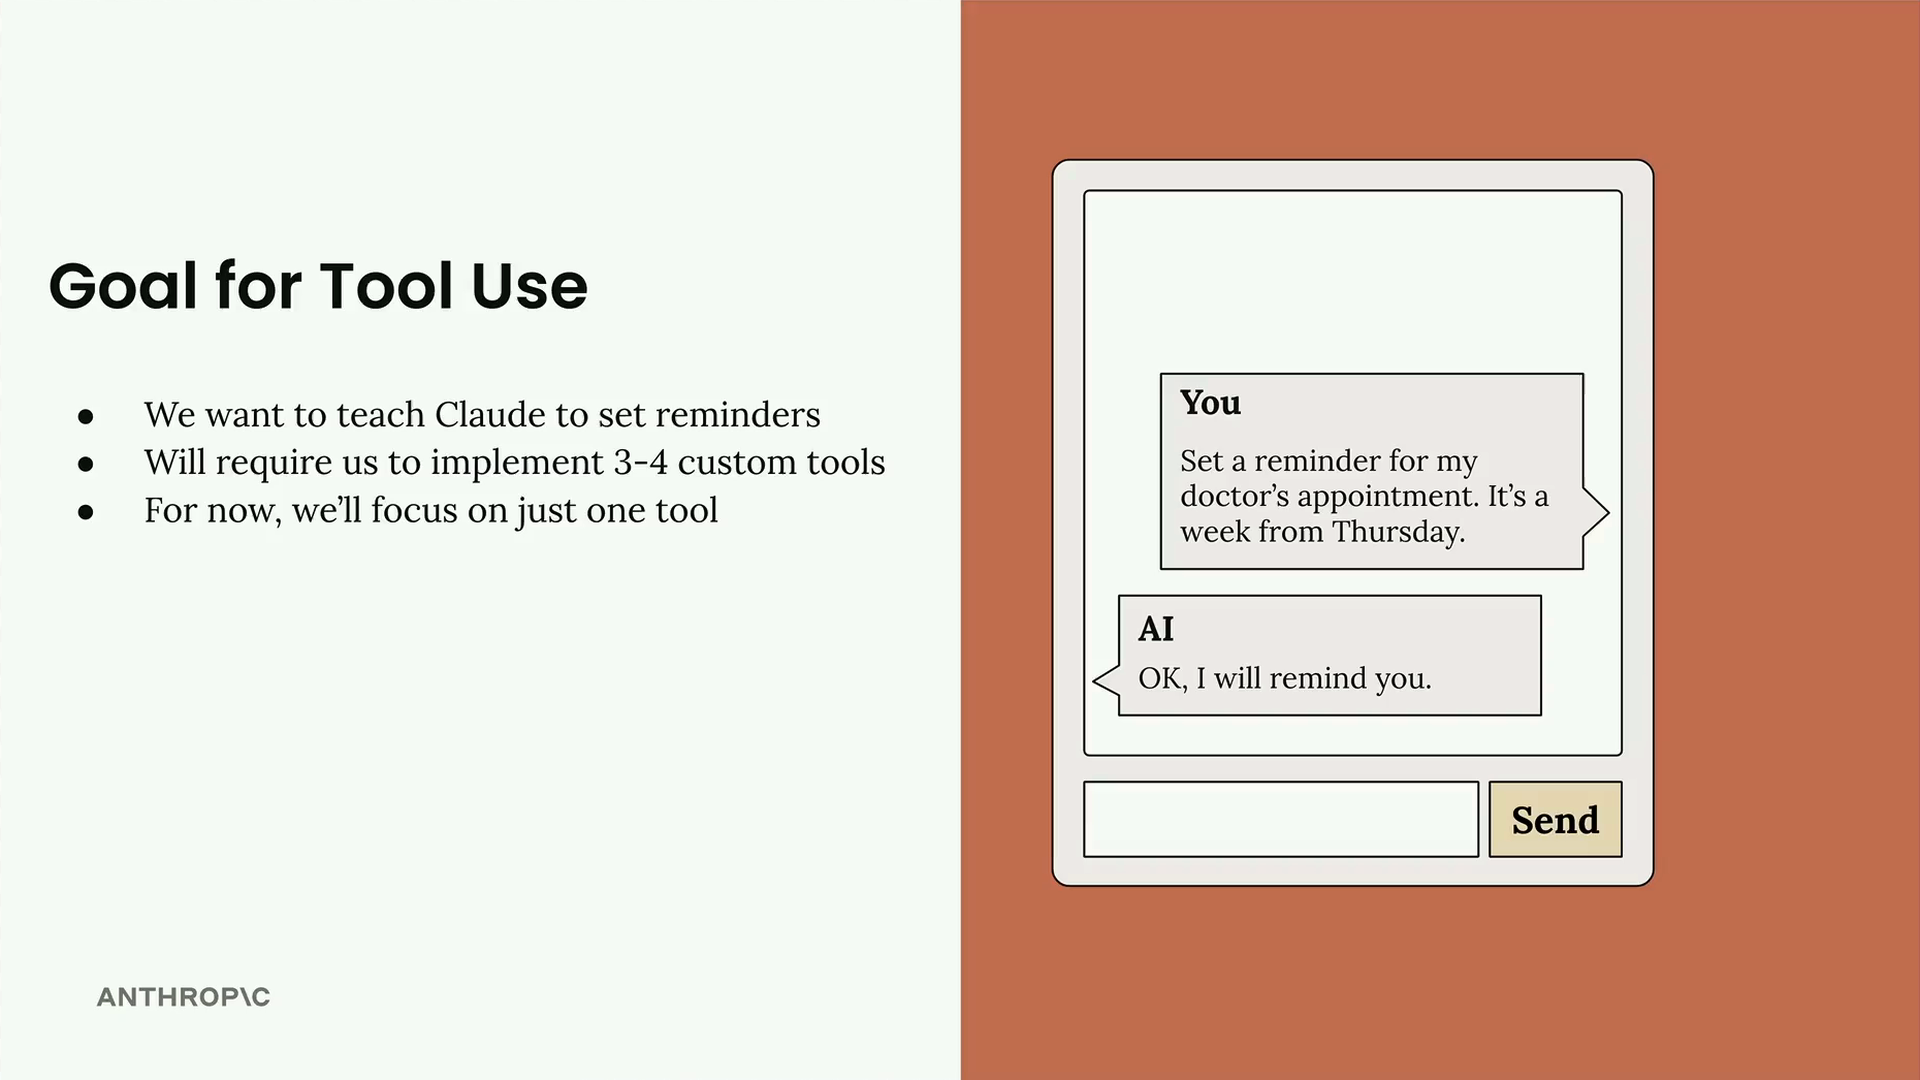

### Why This Is Challenging

While Claude knows the current date, there are three specific problems we need to solve:

    Limited time awareness: Claude might know the current date, but not the exact time
    Date calculation issues: Claude doesn't always handle time-based addition well, especially when looking many days into the future
    No reminder capability: Claude doesn't know how to set a reminder - it has no built-in mechanism for this

Each of these limitations represents a gap between what Claude can do naturally and what we need for our reminder system. Tools are how we bridge these gaps.


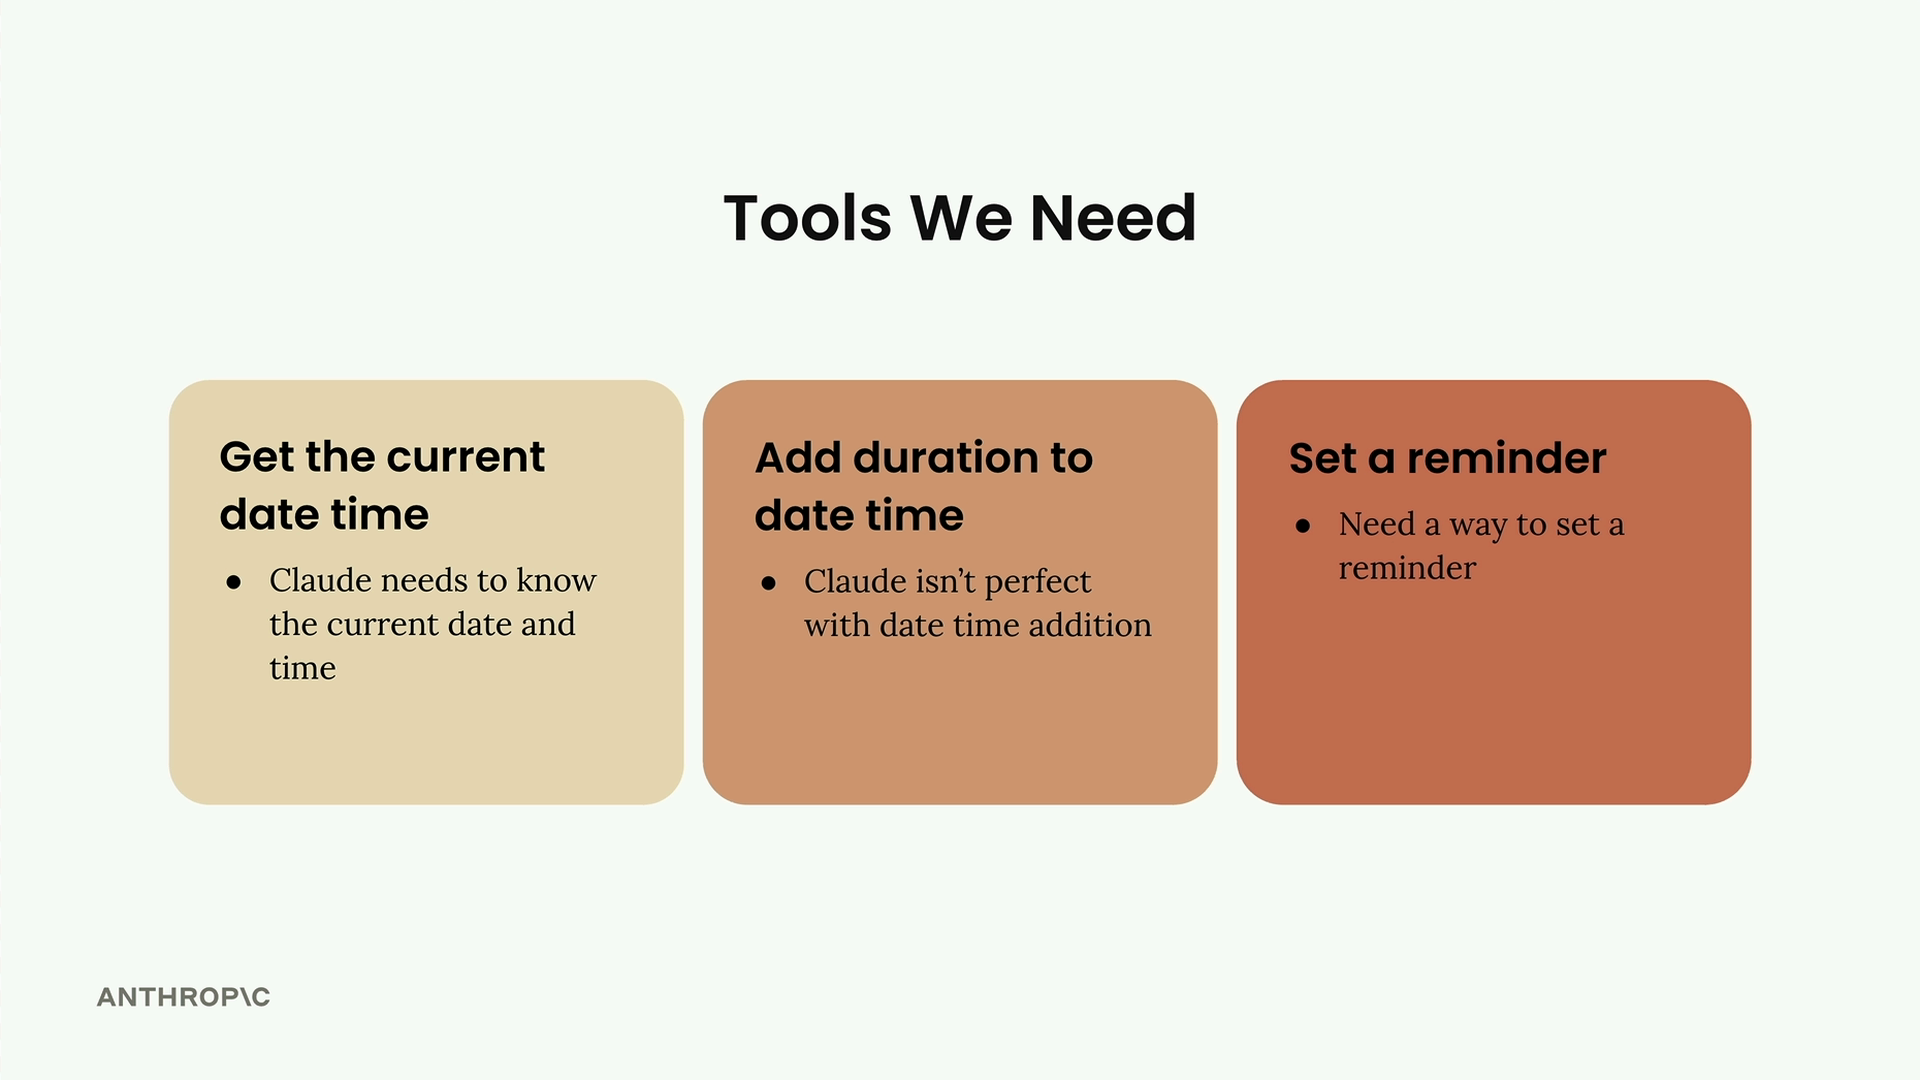


We'll create three separate tools to handle each challenge:

    Get the current date time: Claude needs to know the current date and time precisely
    Add duration to date time: Claude isn't perfect with date time addition, so we'll give it a reliable tool for this
    Set a reminder: We need a way to actually set a reminder in the system

We'll implement these tools one at a time, starting with the simplest one. This approach lets us understand how tool calling works before building more complex functionality. By the end, Claude will be able to handle natural language requests like "remind me in a week" by combining these tools to calculate the exact time and set the reminder.

This project demonstrates a key principle of working with AI: when the model has limitations, we extend its capabilities through tools rather than trying to work around those limitations in our prompts.

### What Are Tool Functions?

A tool function is a plain Python function that gets executed automatically when Claude decides it needs extra information to help a user. For example, if someone asks "What time is it?", Claude would call your date/time tool to get the current time.

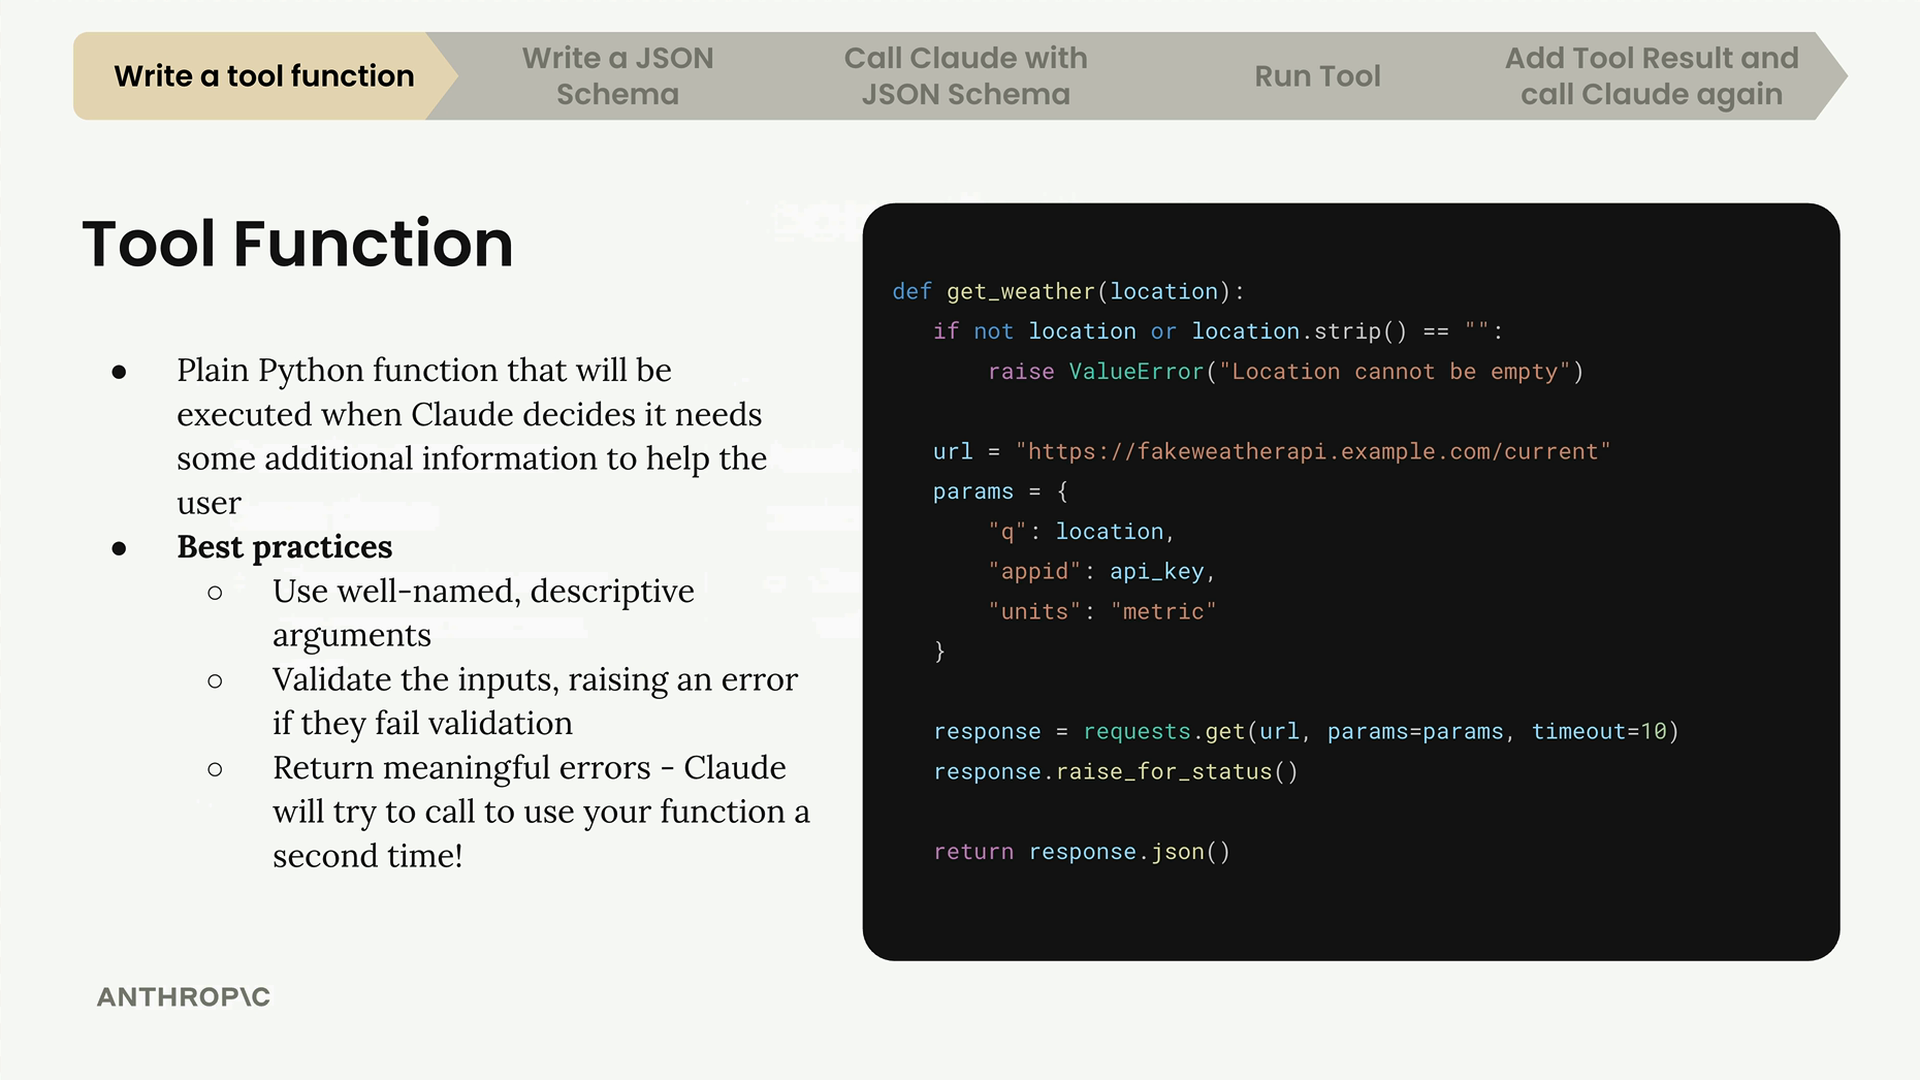


### Best Practices for Tool Functions

When writing tool functions, follow these guidelines:

    Use descriptive names: Both your function name and parameter names should clearly indicate their purpose
    Validate inputs: Check that required parameters aren't empty or invalid, and raise errors when they are
    Provide meaningful error messages: Claude can see error messages and might retry the function call with corrected parameters

The validation is particularly important because Claude learns from errors. If you raise a clear error like "Location cannot be empty", Claude might try calling the function again with a proper location value.

## Understanding JSON Schema

JSON Schema isn't specific to AI or tool calling - it's a widely-used data validation specification that's been around for years. The AI community adopted it because it's a convenient way to describe function parameters and validate data.

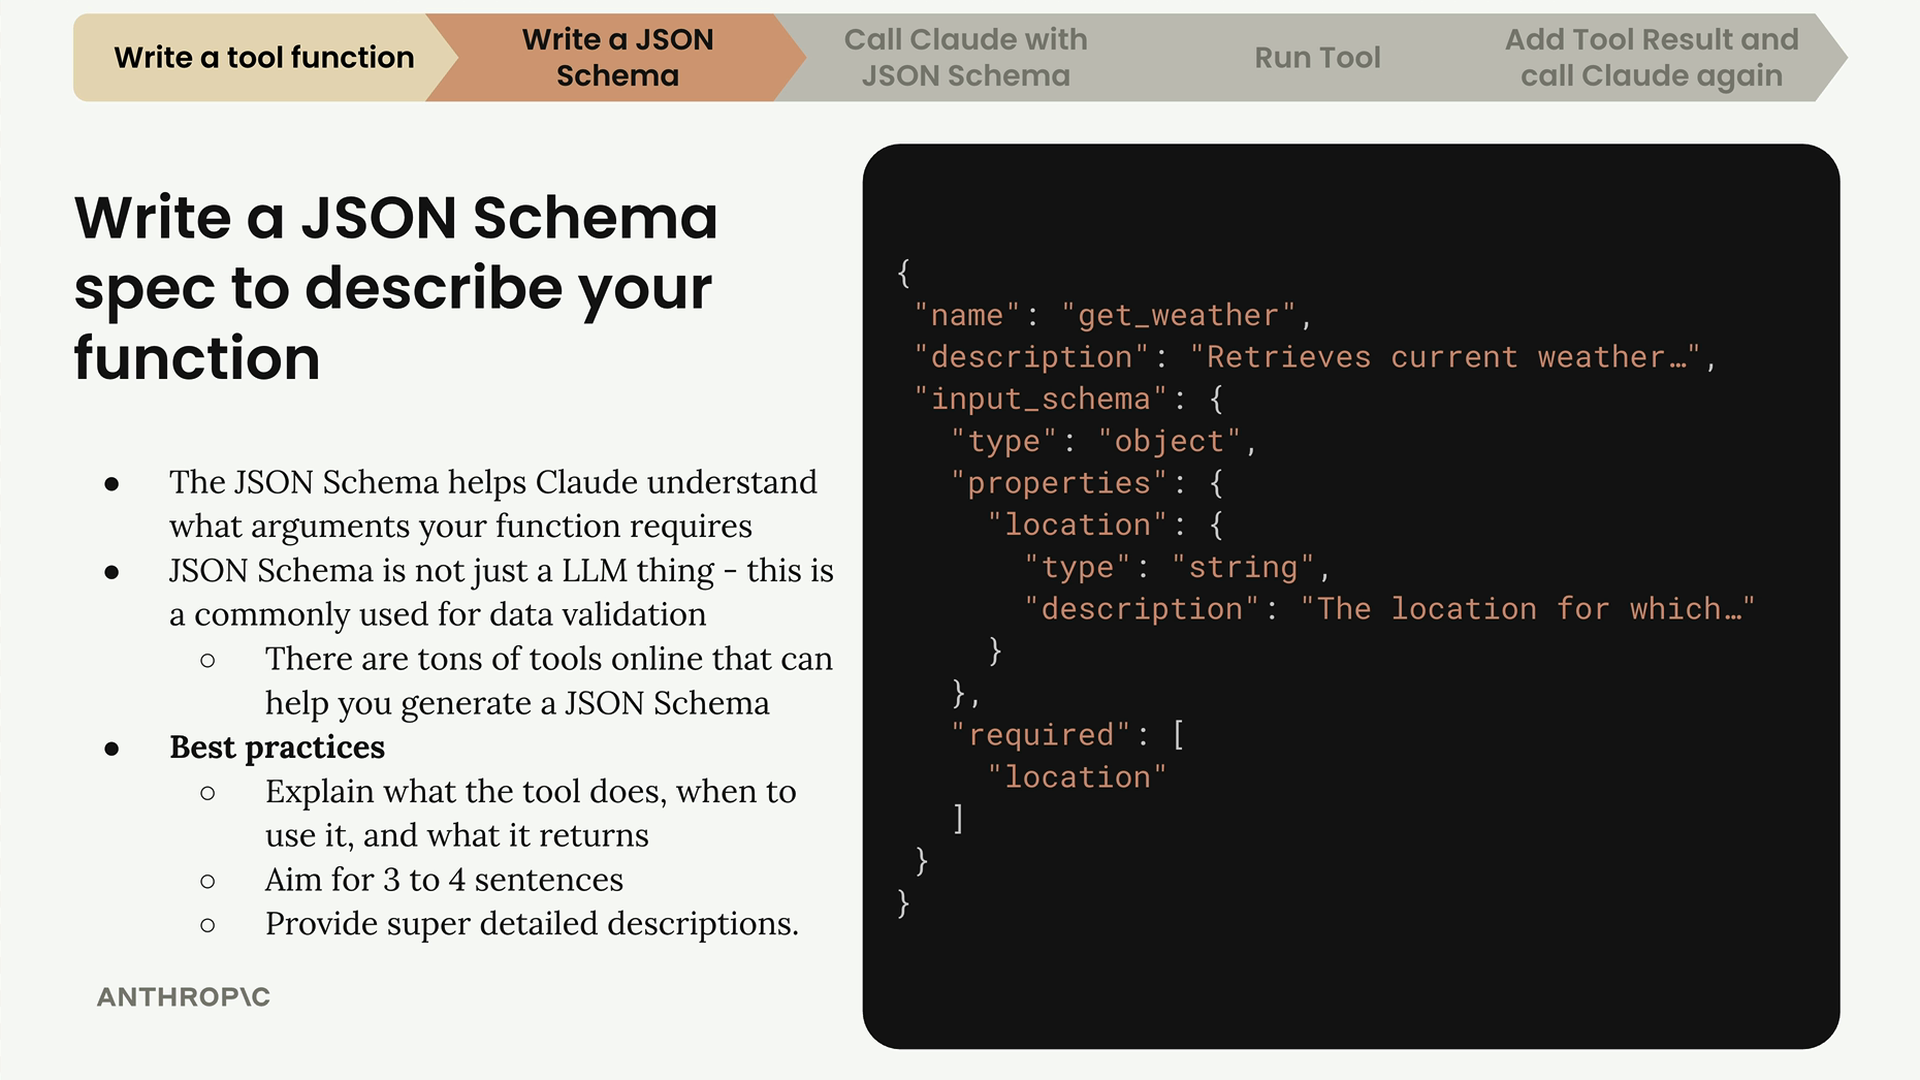

The complete tool specification has three main parts:

    name - A clear, descriptive name for your tool (like "get_weather")
    description - What the tool does, when to use it, and what it returns
    input_schema - The actual JSON schema describing the function's arguments
Writing Effective Descriptions

Your tool description is crucial for helping Claude understand when to use your function. Best practices include:

    Aim for 3-4 sentences explaining what the tool does
    Describe when Claude should use it
    Explain what kind of data it returns
    Provide detailed descriptions for each argument

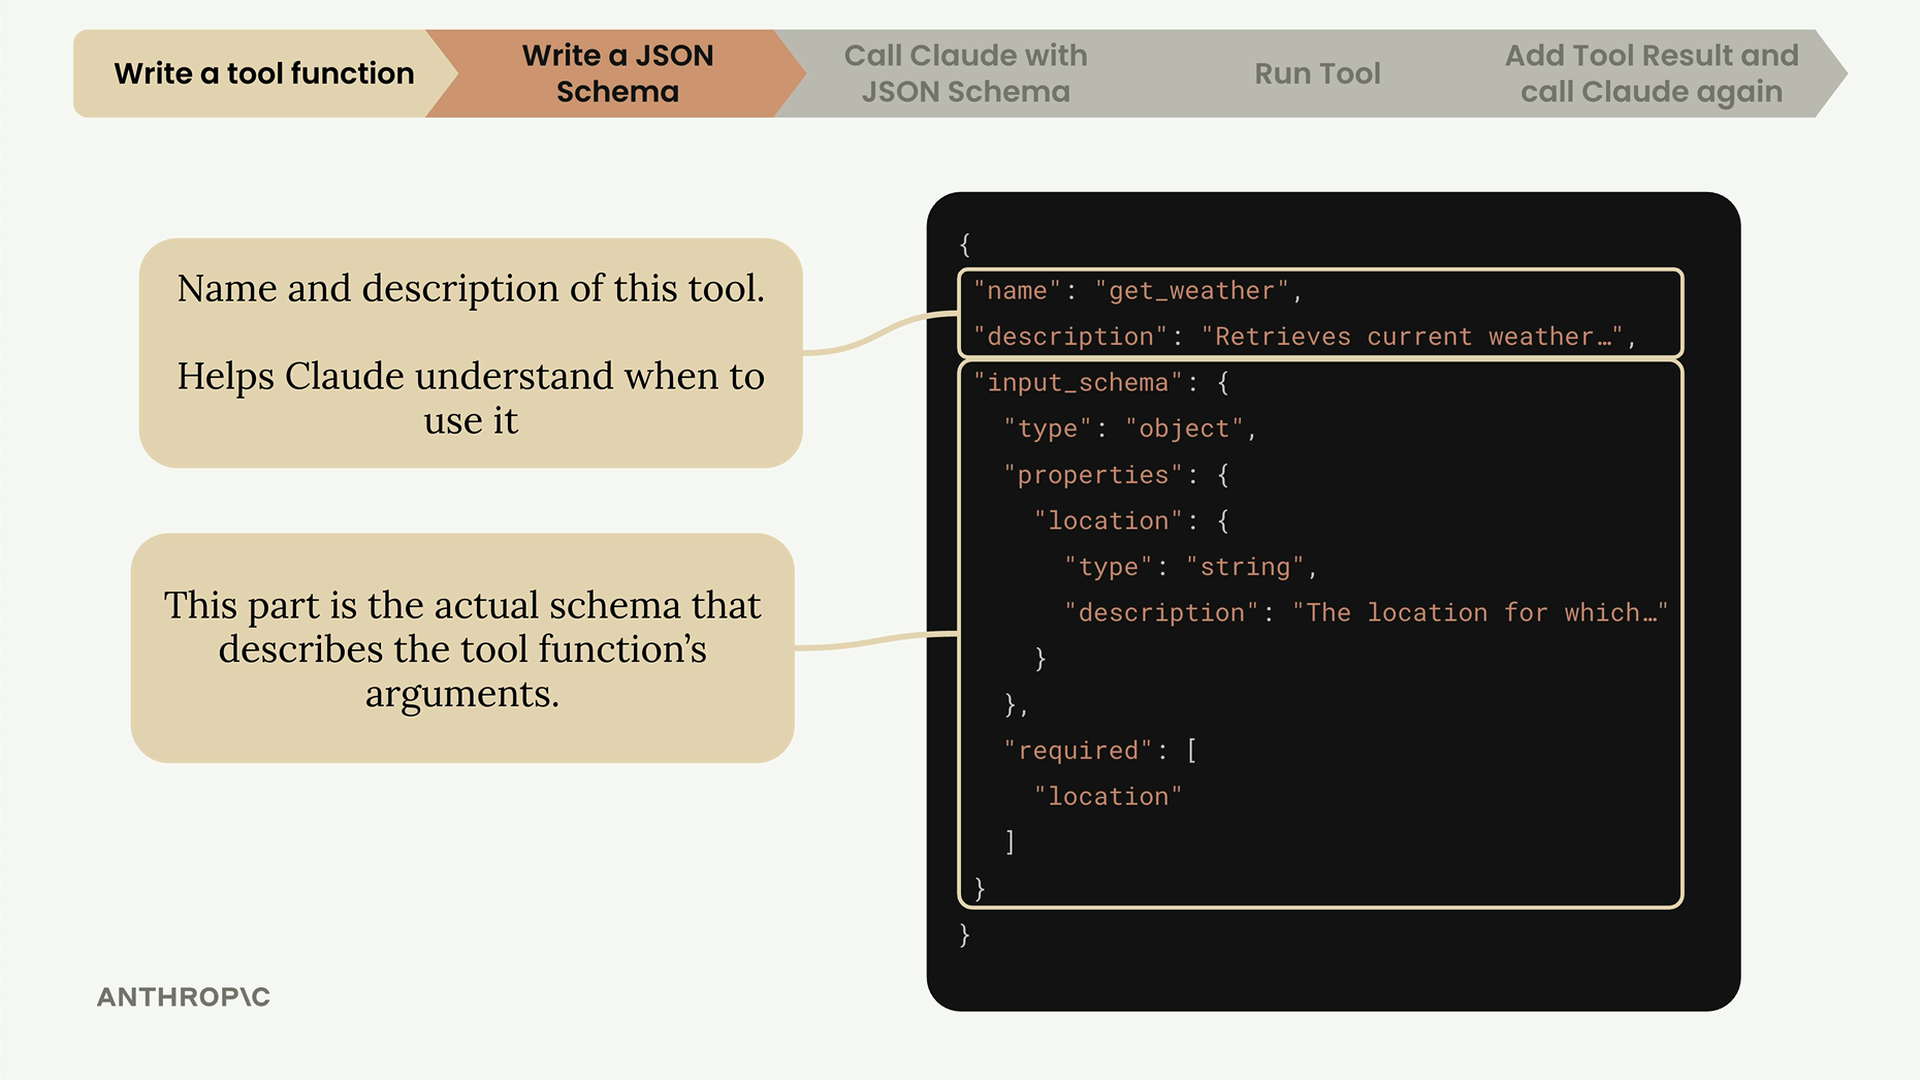


The Easy Way to Generate Schemas

Instead of writing JSON schemas from scratch, you can use Claude itself to generate them. Here's the process:

    Copy your tool function code
    Go to Claude and ask it to write a JSON schema for tool calling
    Include the Anthropic documentation on tool use as context
    Let Claude generate a properly formatted schema following best practices

The prompt should be something like: "Write a valid JSON schema spec for the purposes of tool calling for this function. Follow the best practices listed in the attached documentation."

Implementing the Schema in Code

Once Claude generates your schema, copy it into your code file. Here's a good naming pattern to follow:

```python
def get_current_datetime(date_format="%Y-%m-%d %H:%M:%S"):
    if not date_format:
        raise ValueError("date_format cannot be empty")
    return datetime.now().strftime(date_format)

get_current_datetime_schema = {
    "name": "get_current_datetime",
    "description": "Returns the current date and time formatted according to the specified format",
    "input_schema": {
        "type": "object",
        "properties": {
            "date_format": {
                "type": "string",
                "description": "A string specifying the format of the returned datetime. Uses Python's strftime format codes.",
                "default": "%Y-%m-%d %H:%M:%S"
            }
        },
        "required": []
    }
}
```

Use the pattern of function_name followed by function_name_schema to keep your schemas organized and easy to match with their corresponding functions.
Adding Type Safety

For better type checking, import and use the ToolParam type from the Anthropic library:

```python
from anthropic.types import ToolParam

get_current_datetime_schema = ToolParam({
    "name": "get_current_datetime",
    "description": "Returns the current date and time formatted according to the specified format",
    # ... rest of schema
})
```

While not strictly necessary for functionality, this prevents type errors when you use the schema with Claude's API and makes your code more robust.

When working with Claude's tool functionality, you'll encounter a new type of response structure that's different from the simple text responses you've seen before. Instead of just getting back a single text block, Claude can now return multi-block messages that contain both text and tool usage information.
Making Tool-Enabled API Calls

To enable Claude to use tools, you need to include a tools parameter in your API call. Here's how to structure the request:

```python
messages = []
messages.append({
    "role": "user",
    "content": "What is the exact time, formatted as HH:MM:SS?"
})

response = client.messages.create(
    model=model,
    max_tokens=1000,
    messages=messages,
    tools=[get_current_datetime_schema],
)
```

The tools parameter takes a list of JSON schemas that describe the available functions Claude can call.

### Understanding Multi-Block Messages


When Claude decides to use a tool, it returns an assistant message with multiple blocks in the content list. This is a significant change from the simple text-only responses you've worked with before.

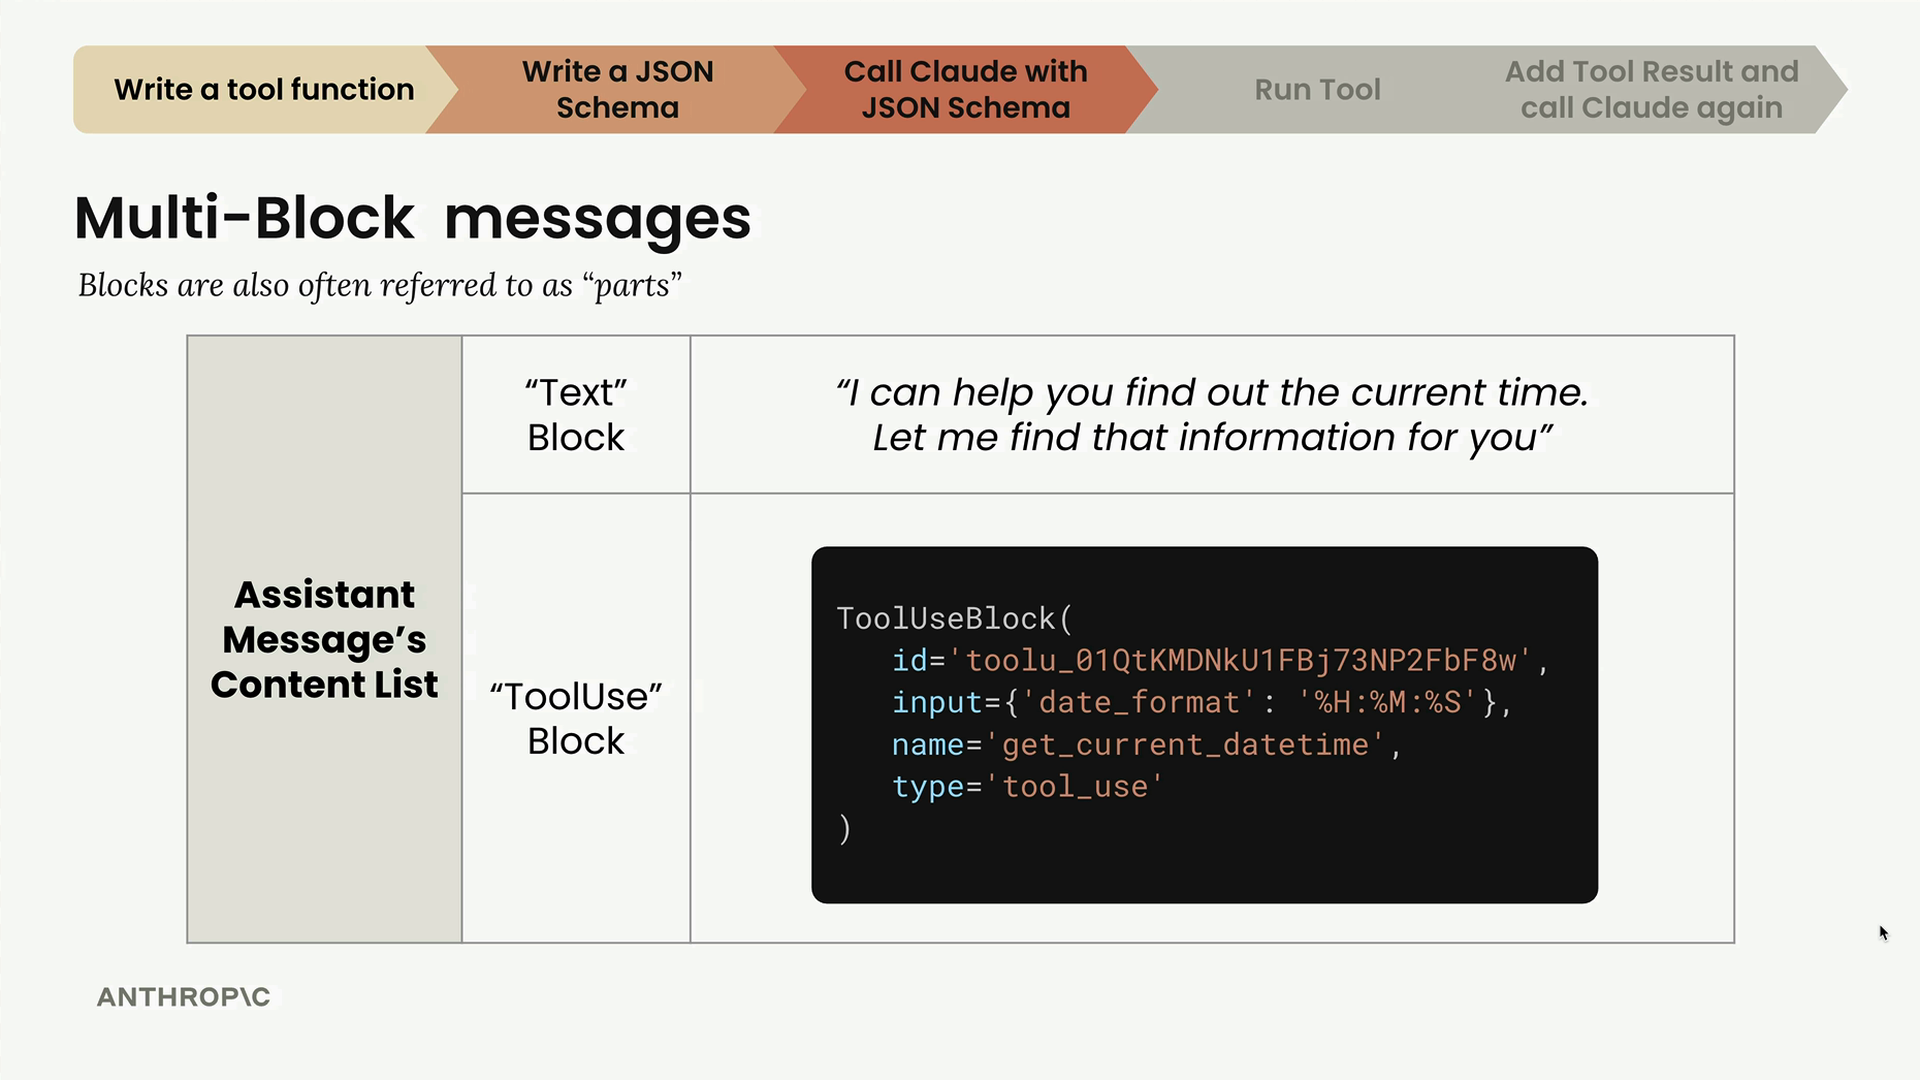

A multi-block message typically contains:

    Text Block - Human-readable text explaining what Claude is doing (like "I can help you find out the current time. Let me find that information for you")
    ToolUse Block - Instructions for your code about which tool to call and what parameters to use

The ToolUse block includes:

    An ID for tracking the tool call
    The name of the function to call (like "get_current_datetime")
    Input parameters formatted as a dictionary
    The type designation "tool_use"



### Managing Conversation History with Multi-Block Messages

Remember that Claude doesn't store conversation history - you need to manage it manually. When working with tool responses, you must preserve the entire content structure, including all blocks.

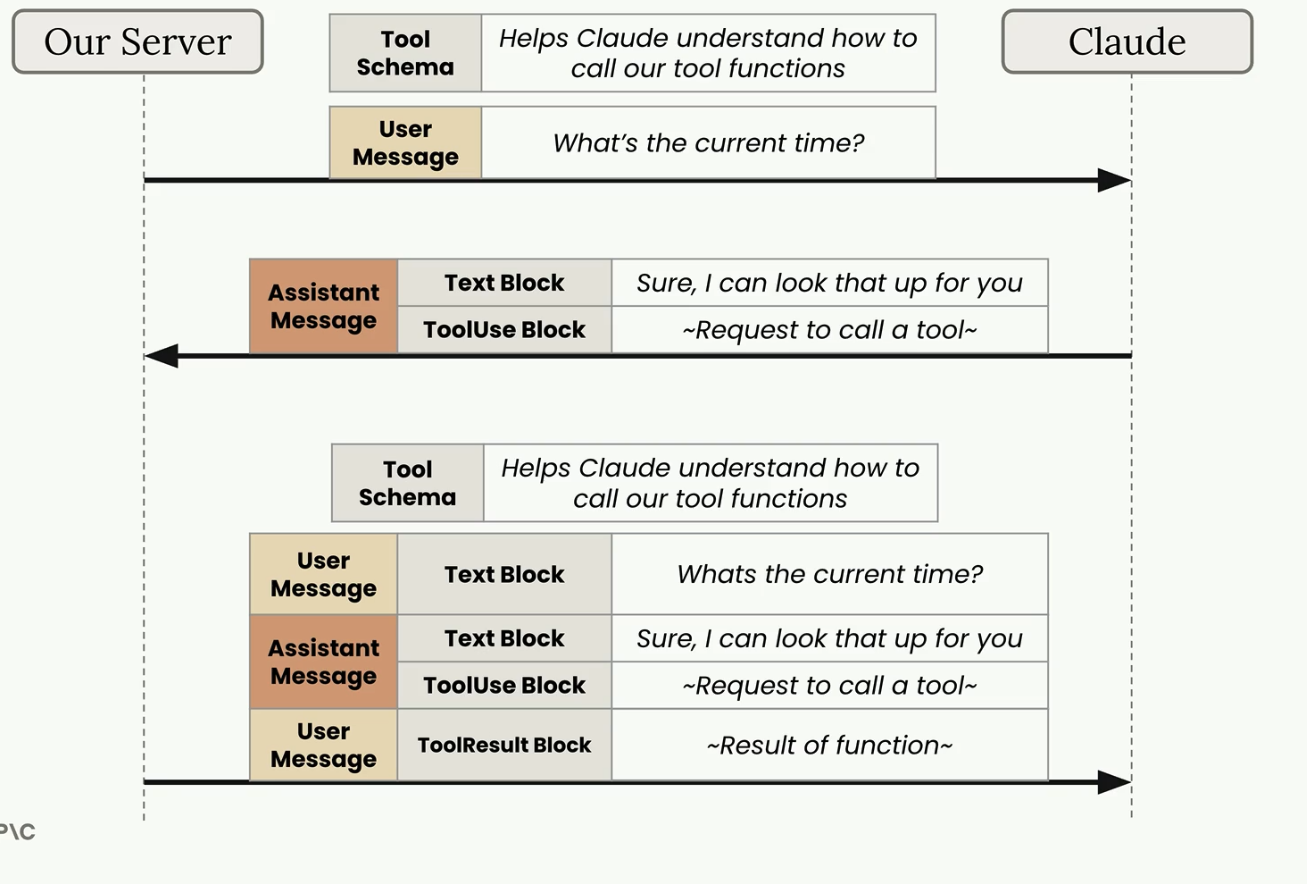

Here's how to properly append a multi-block assistant message to your conversation history:
```python
messages.append({
    "role": "assistant",
    "content": response.content
})
```

### The Complete Tool Usage Flow

The tool usage process follows this pattern:

    Send user message with tool schema to Claude
    Receive assistant message with text block and tool use block
    Extract tool information and execute the actual function
    Send tool result back to Claude along with complete conversation history
    Receive final response from Claude

Each step requires careful handling of the message structure to ensure Claude has the full context it needs to provide accurate responses.



### Updating Helper Functions

If you've been using helper functions like add_user_message() and add_assistant_message(), you'll need to update them to handle multi-block content. The current versions likely only support single text blocks, but now they need to accommodate the more complex content structures that include tool use blocks.

This multi-block message handling is essential for building robust applications that can seamlessly integrate Claude's tool capabilities while maintaining proper conversation flow.


### Running the Tool Function

When Claude responds with a tool use block, you extract the input parameters and call your function. Here's how to access the tool parameters:

response.content[1].input

This gives you a dictionary of the arguments Claude wants to pass to your function. Since your function expects keyword arguments rather than a dictionary, you use Python's unpacking syntax:

get_current_datetime(**response.content[1].input)

### Tool Result Block

After running the tool function, you need to send the results back to Claude using a tool result block. This block goes inside a user message and tells Claude what happened when you executed the tool.

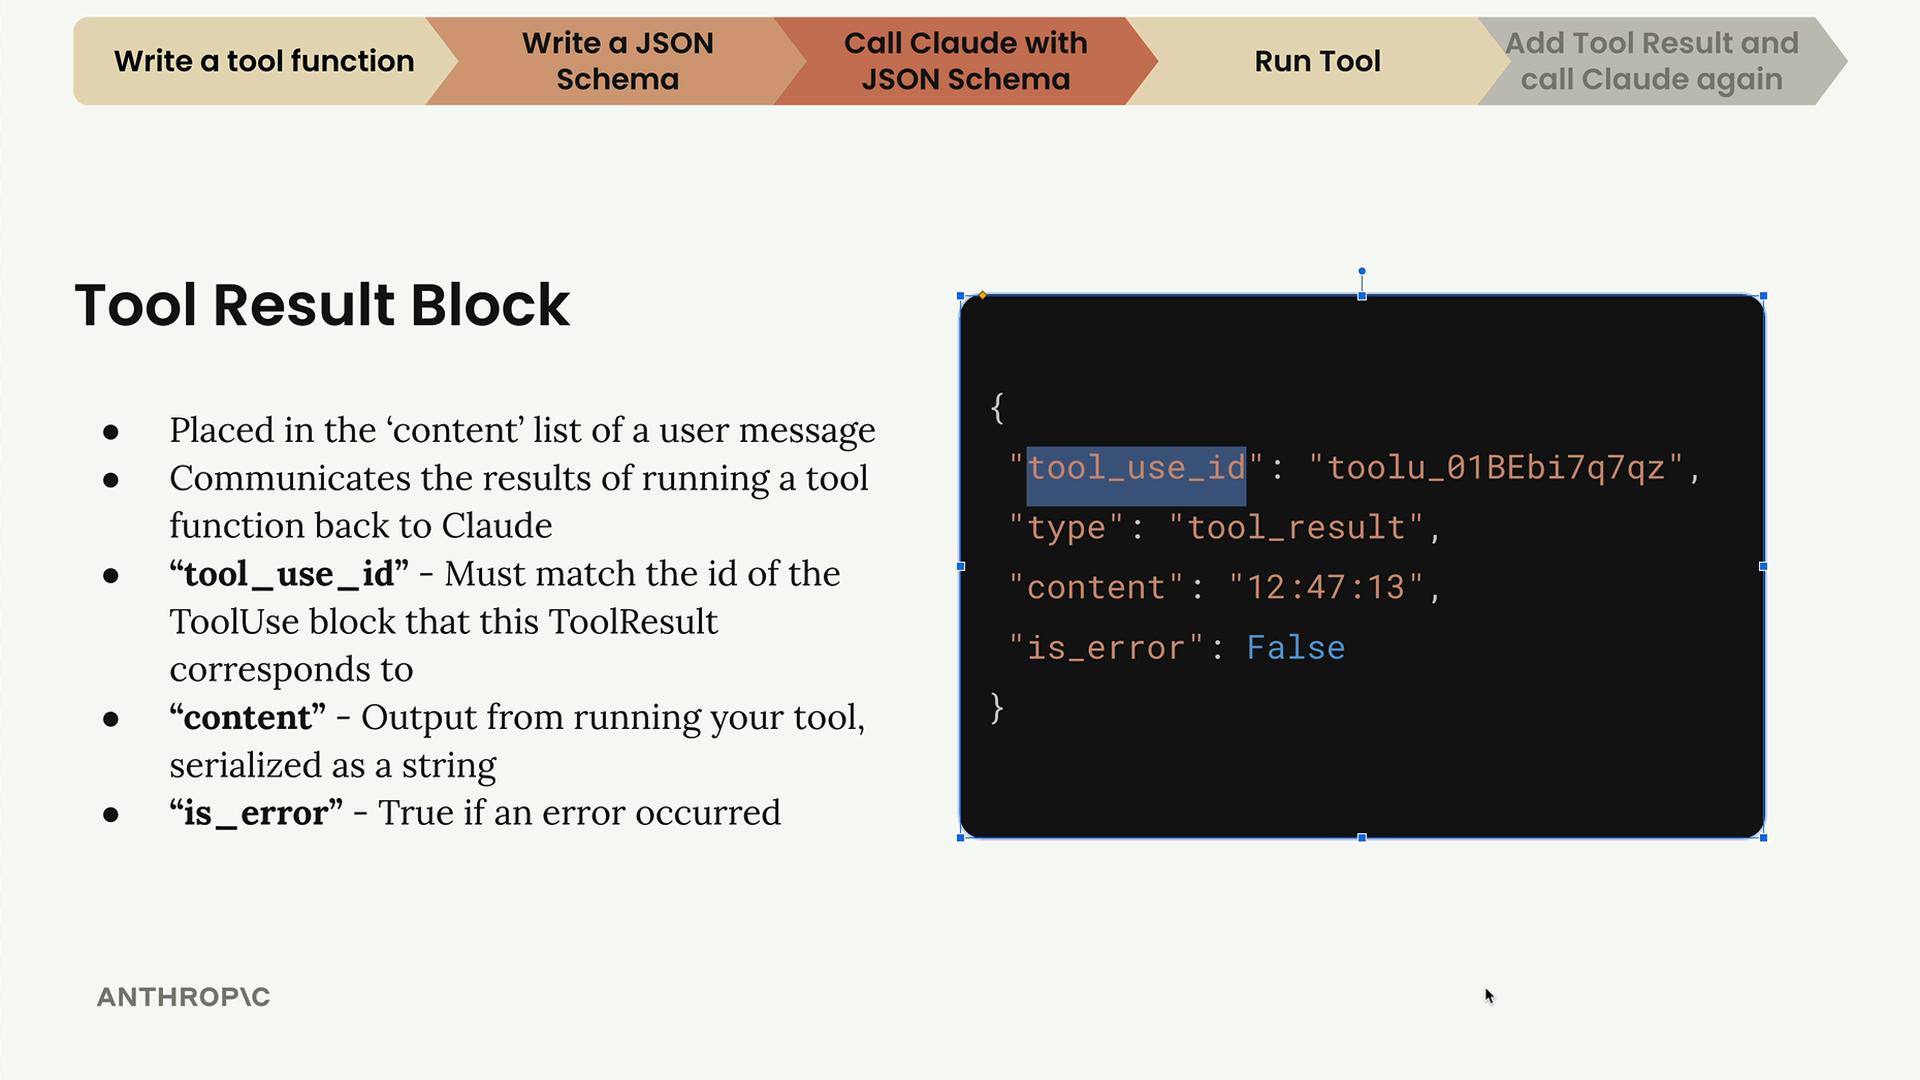


The tool result block has several important properties:

    tool_use_id - Must match the id of the ToolUse block that this ToolResult corresponds to
    content - Output from running your tool, serialized as a string
    is_error - True if an error occurred

### Handling Multiple Tool Calls

Claude can request multiple tool calls in a single response. For example, if a user asks "What's 10 + 10 and what's 30 + 30?", Claude might respond with two separate ToolUse blocks.

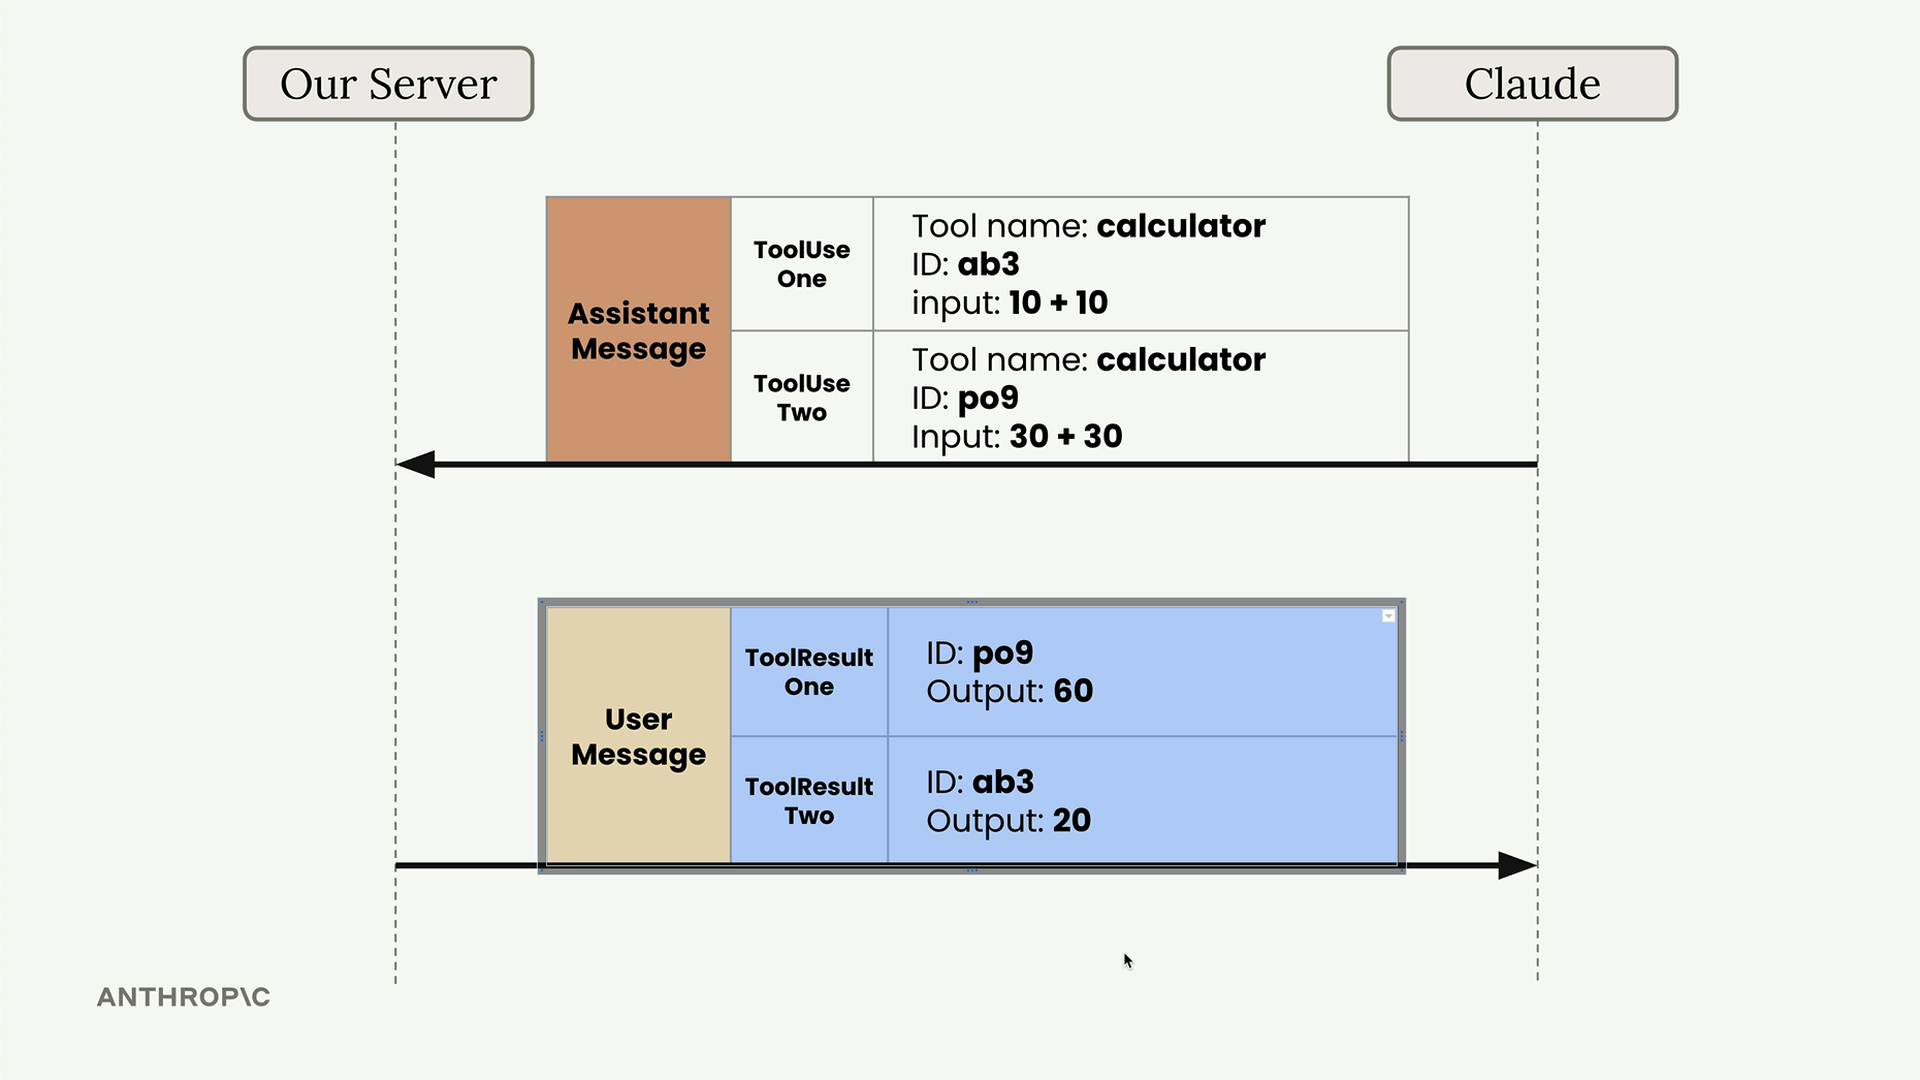

Each tool call gets a unique ID, and you must match these IDs when sending back results. This ensures Claude knows which result corresponds to which request, even if the results arrive in a different order.

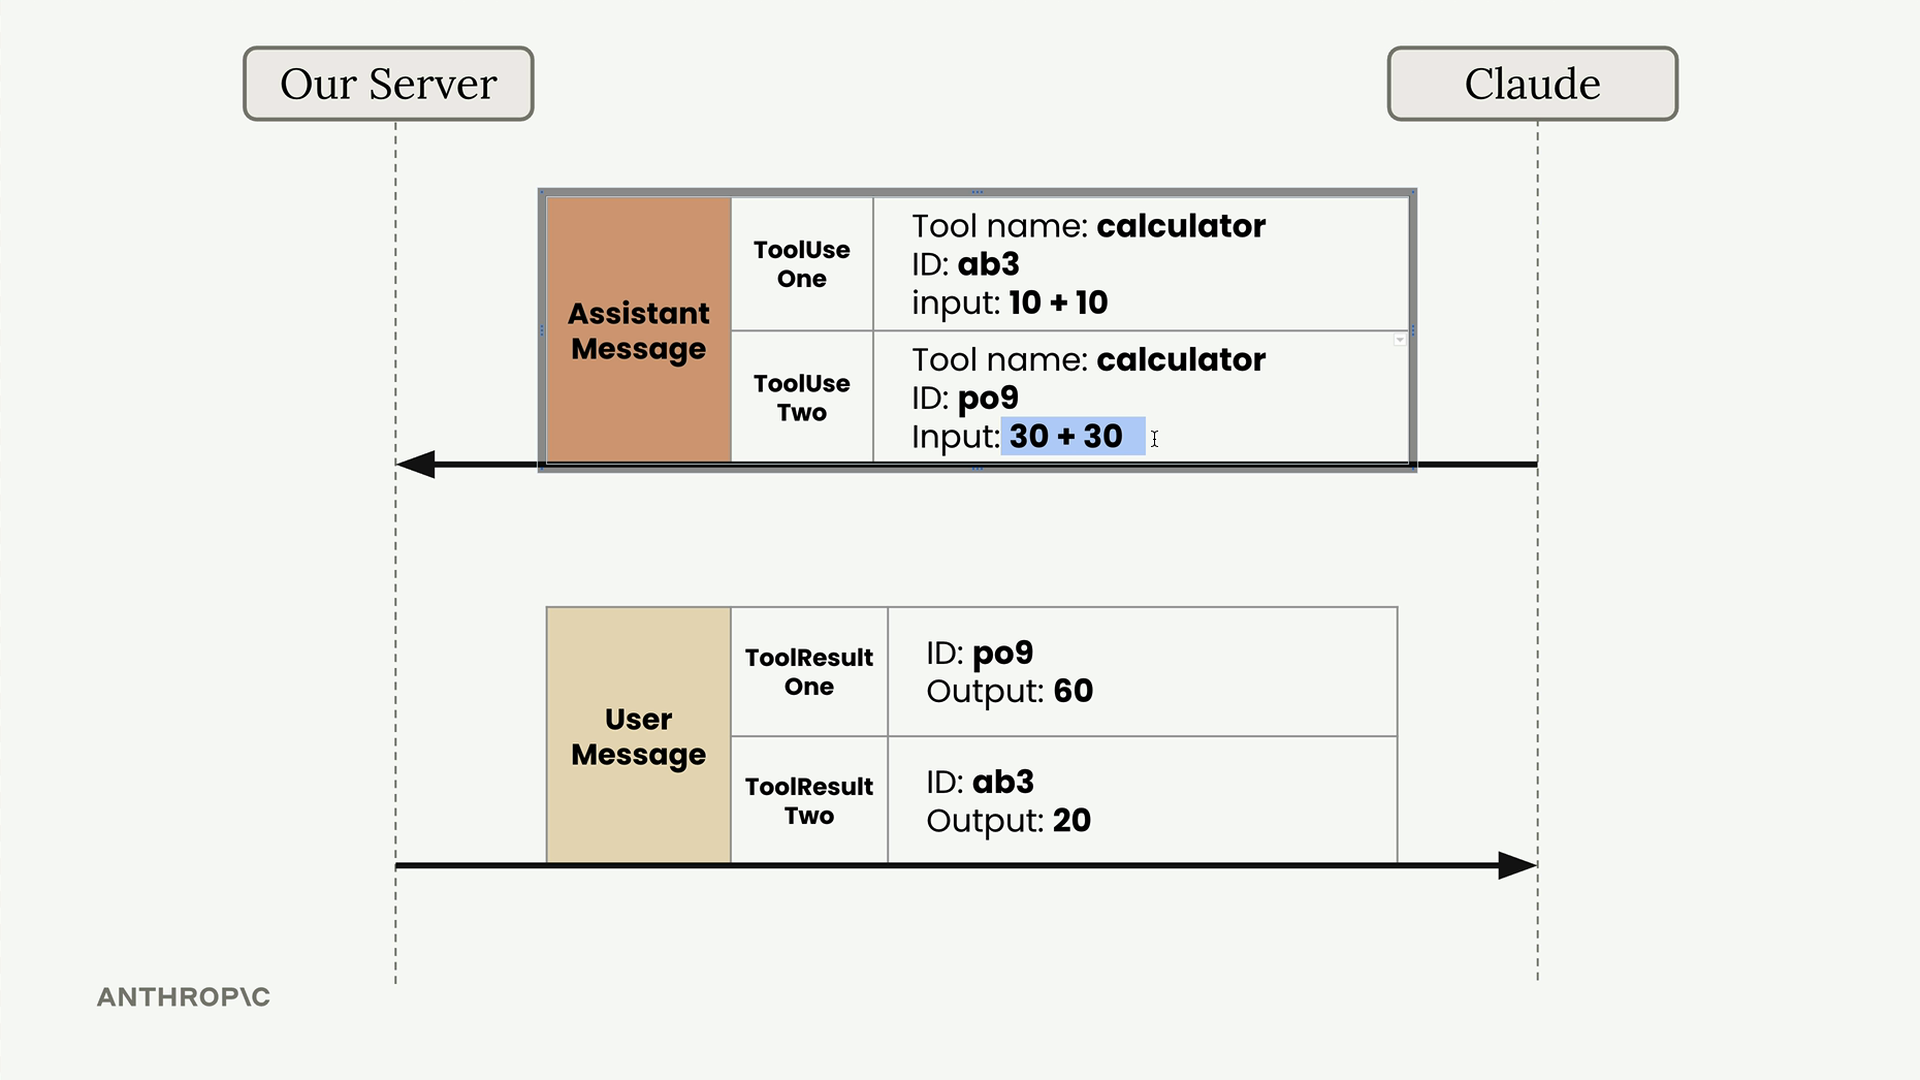


### Building the Follow-up Request

Your follow-up request to Claude must include the complete conversation history plus the new tool result. Here's the structure:

```python
messages.append({
    "role": "user",
    "content": [{
        "type": "tool_result",
        "tool_use_id": response.content[1].id,
        "content": "15:04:22",
        "is_error": False
    }]
})
```



The complete message history now contains:

    Original user message
    Assistant message with tool use block
    User message with tool result block



### Making the Final Request

When sending the follow-up request, you must still include the tool schema even though you're not expecting Claude to make another tool call. Claude needs the schema to understand the tool references in your conversation history.

client.messages.create(
    model=model,
    max_tokens=1000,
    messages=messages,
    tools=[get_current_datetime_schema]
)

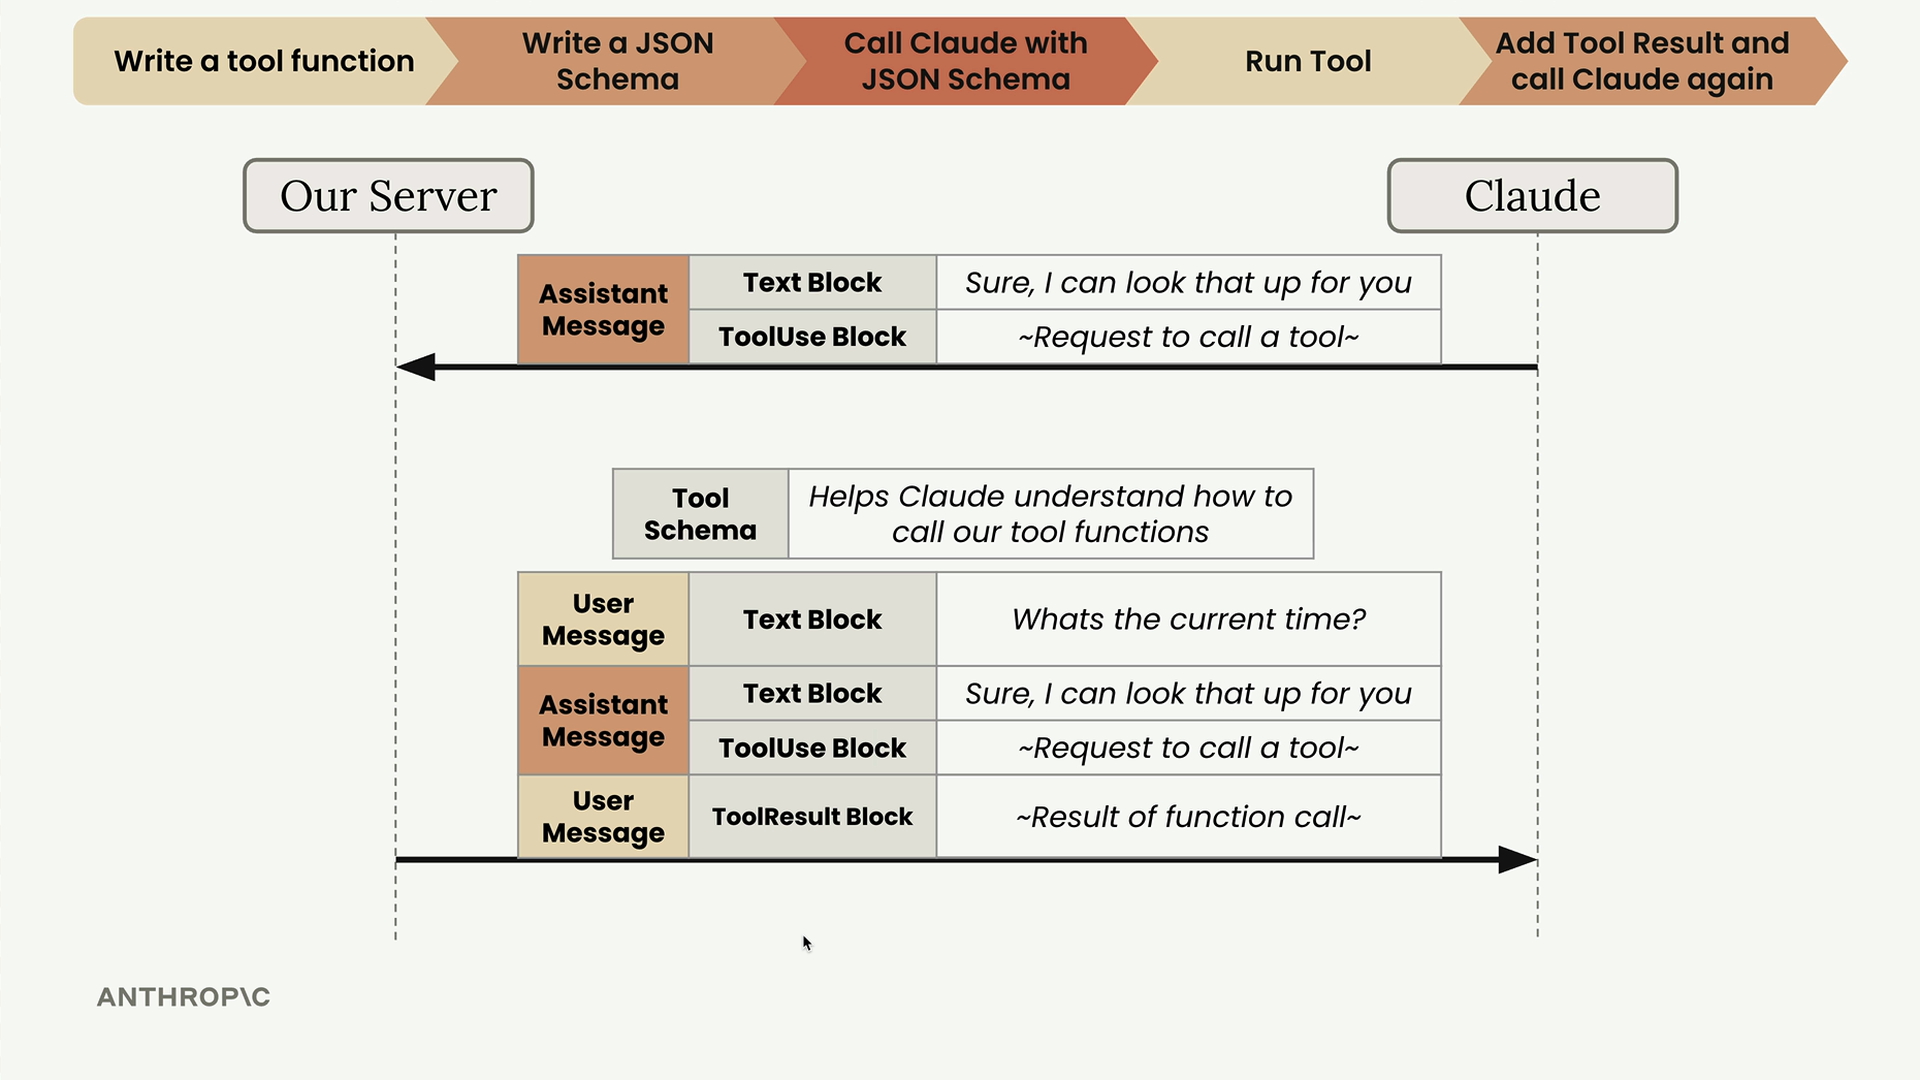


Claude will then respond with a final message that incorporates the tool results into a natural response for the user. The tool use workflow is now complete - you've successfully enabled Claude to access real-time information through your custom function.



When building applications with multiple tools, you need to handle scenarios where Claude might need to call several tools in sequence to answer a single user question. For example, if a user asks "What day is 103 days from today?", Claude needs to first get the current date, then add 103 days to it.


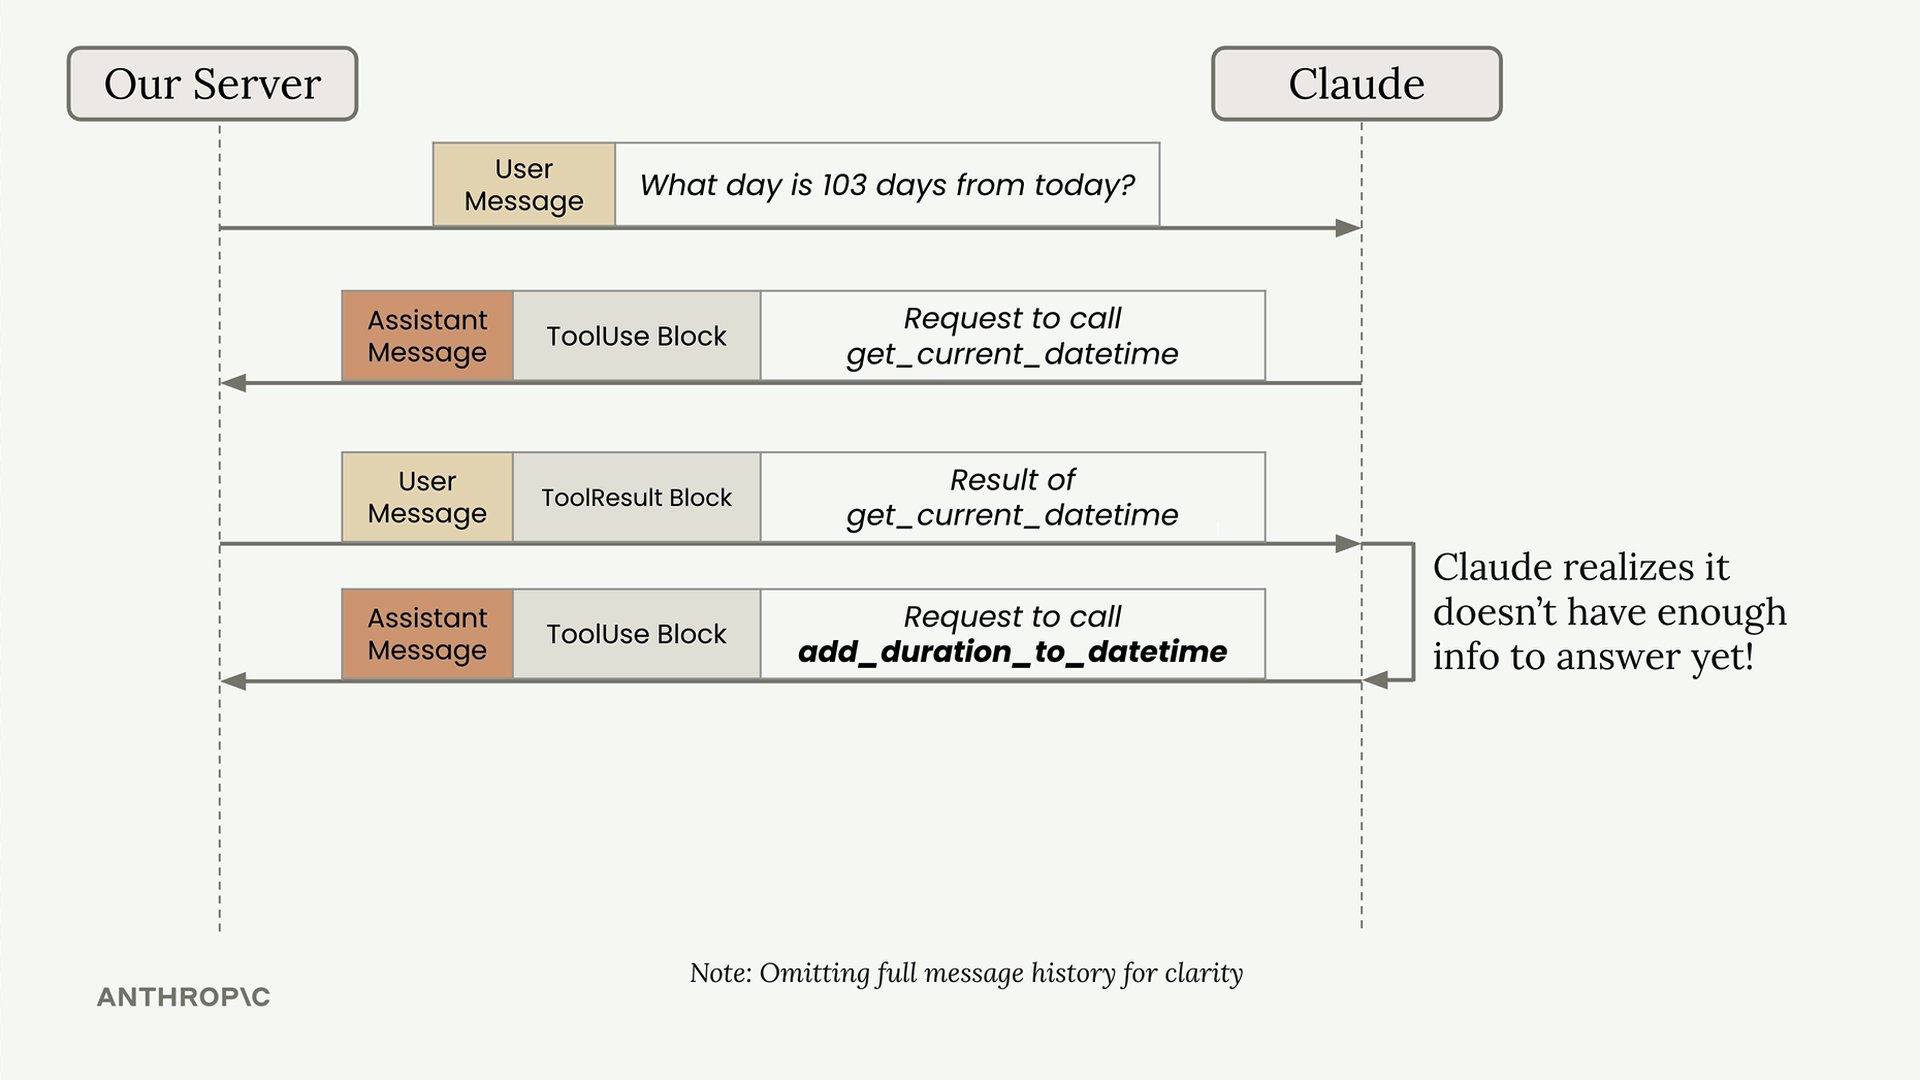


This creates a multi-turn conversation pattern where Claude makes multiple tool requests before providing a final answer. Your application needs to handle this automatically.


### The Multi-Turn Tool Pattern

Here's what happens behind the scenes when Claude needs multiple tools:

    User asks: "What day is 103 days from today?"
    Claude responds with a tool use block requesting get_current_datetime
    Your server calls the function and returns the result
    Claude realizes it needs more information and requests add_duration_to_datetime
    Your server calls that function and returns the result
    Claude now has enough information to provide the final answer


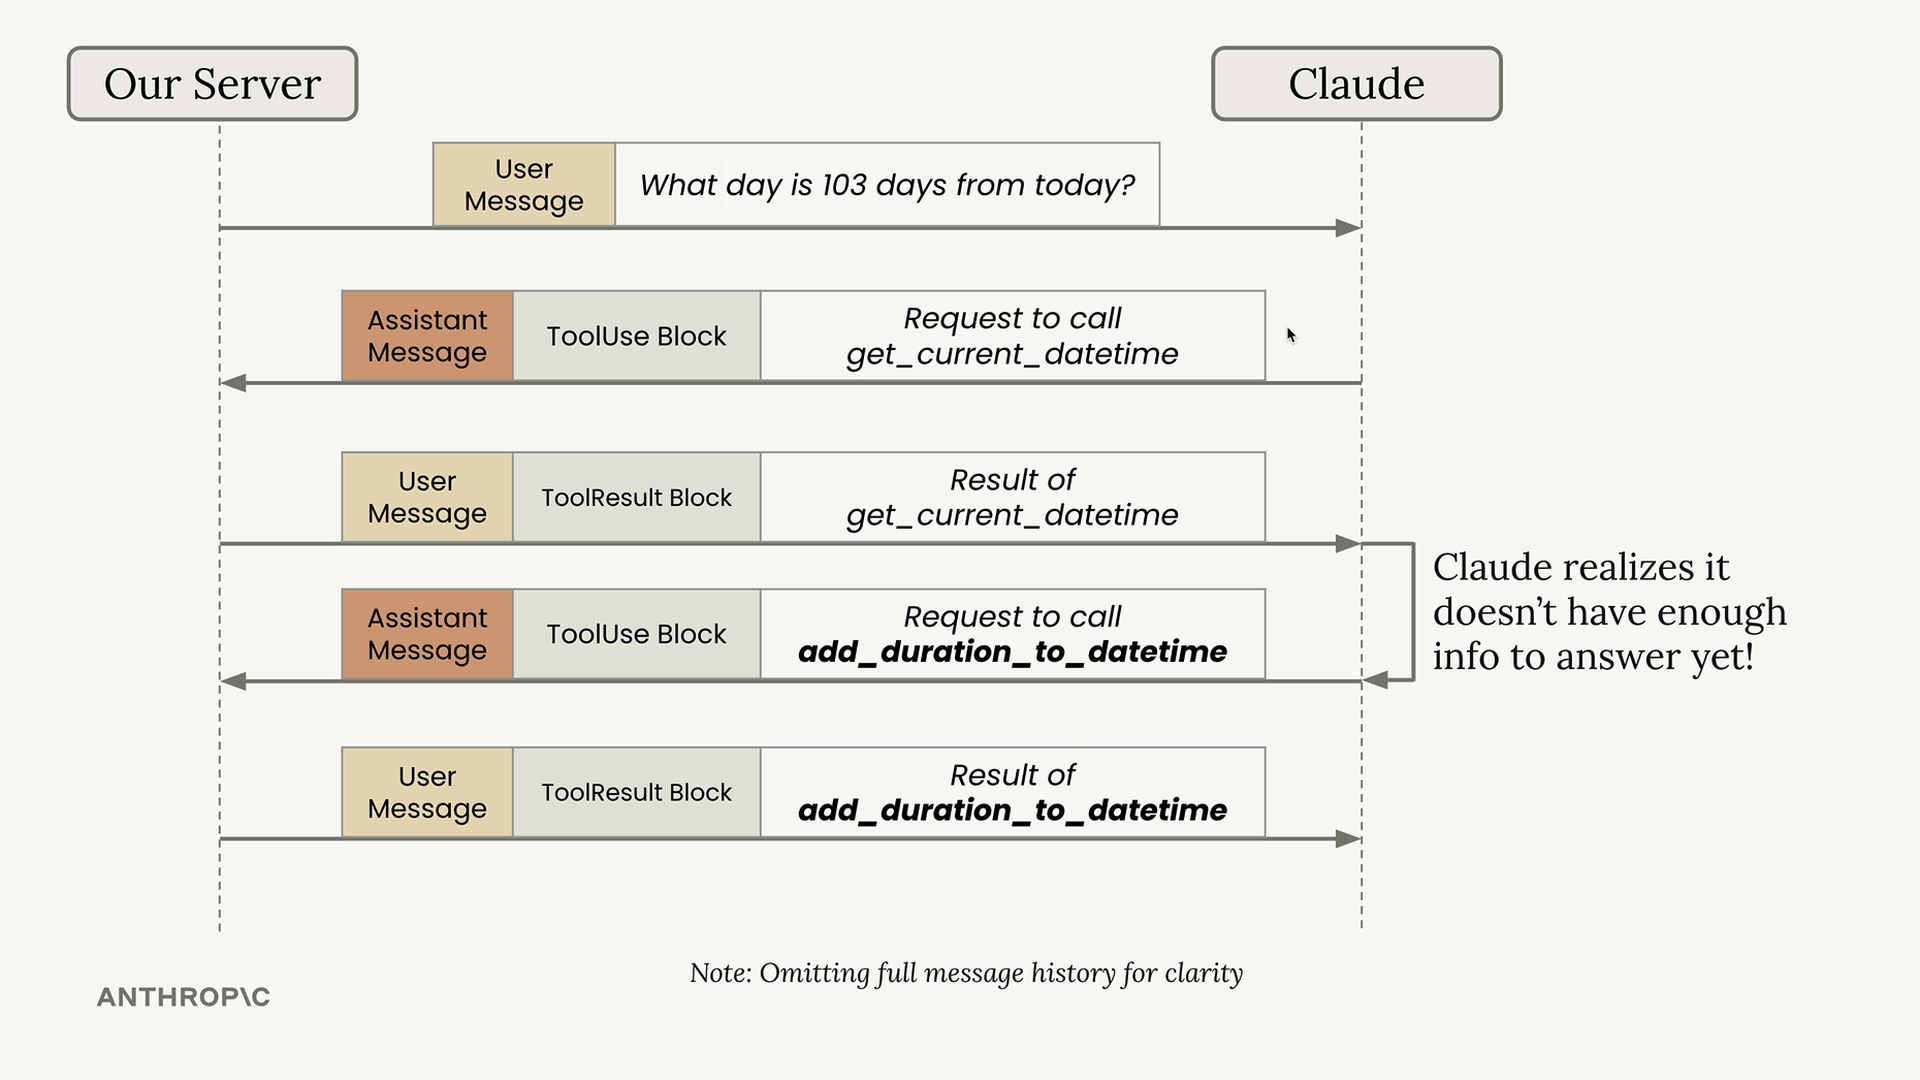

### Building a Conversation Loop

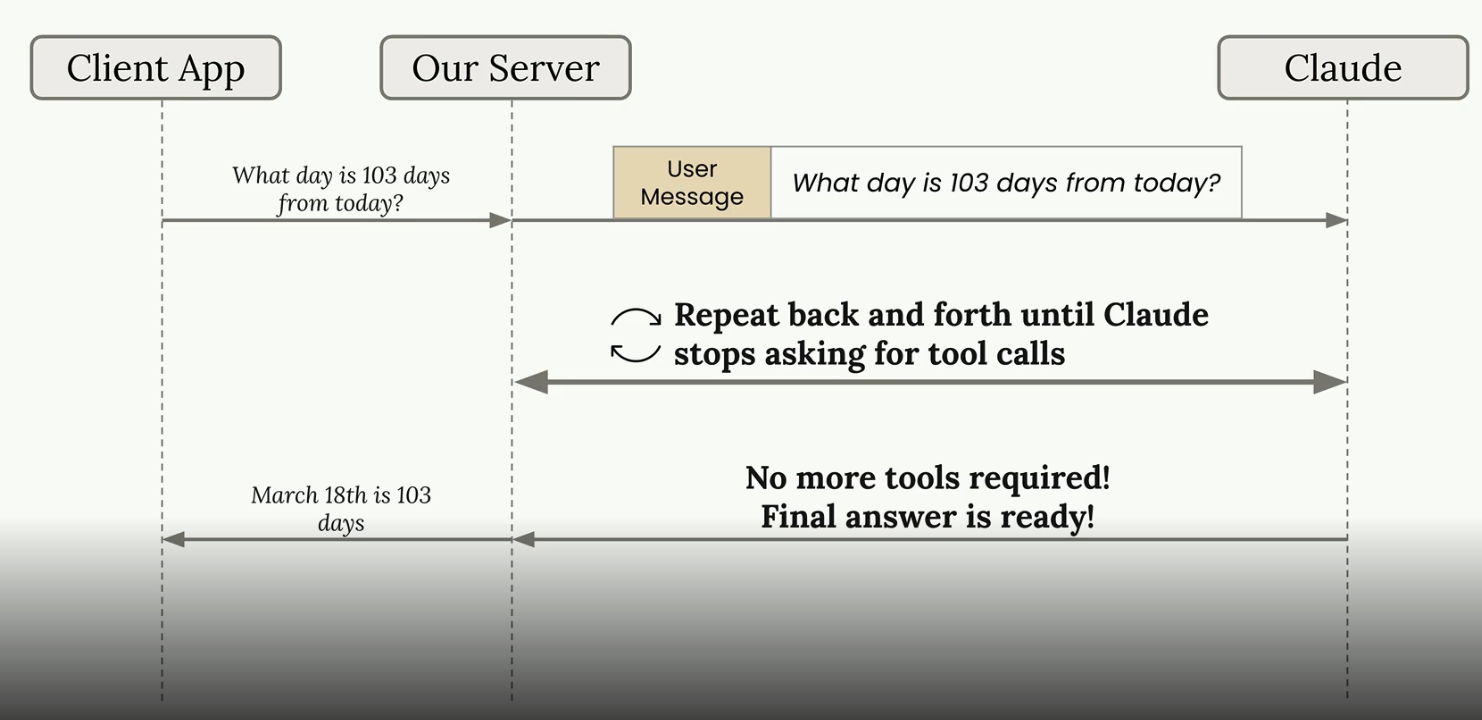

To handle this pattern, you need a conversation loop that continues until Claude stops requesting tools:

```python
def run_conversation(messages):
    while True:
        response = chat(messages)
        
        add_user_message(messages, response)
        
        # Pseudo code
        if response isn't asking for a tool:
            break
            
        tool_result_blocks = run_tools(response)
        add_user_message(tool_result_blocks)
        
    return messages
```

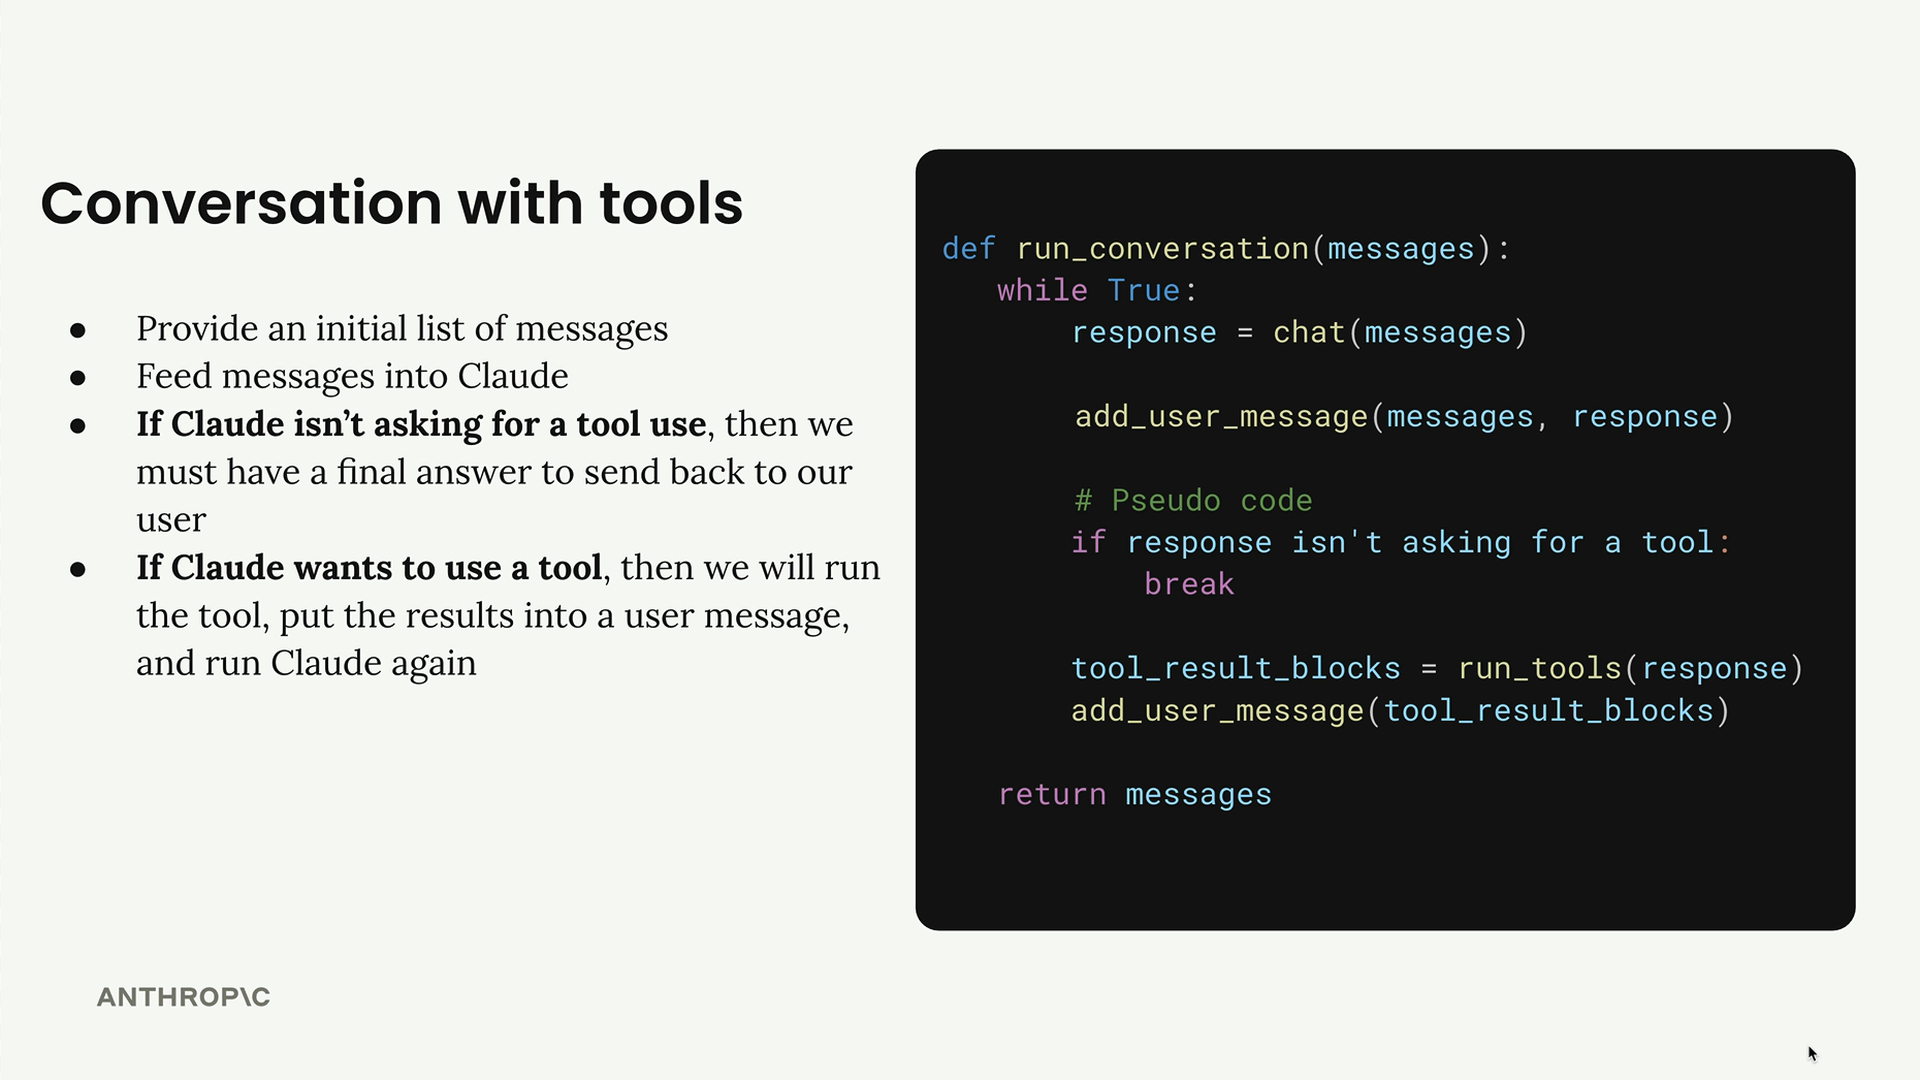

### Refactoring Helper Functions

Before implementing the conversation loop, you need to update your helper functions to handle multiple message blocks properly.

### Updating Message Handlers

Your add_user_message and add_assistant_message functions currently assume you're always working with plain text. Update them to handle full message objects:

```python
from anthropic.types import Message

def add_user_message(messages, message):
    user_message = {
        "role": "user",
        "content": message.content if isinstance(message, Message) else message
    }
    messages.append(user_message)
```

This allows you to pass in either a string, a list of blocks, or a complete message object.

### Updating the Chat Function

Modify your chat function to accept a list of tools and return the full message instead of just text:

```python
def chat(messages, system=None, temperature=1.0, stop_sequences=[], tools=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }
    
    if tools:
        params["tools"] = tools
        
    if system:
        params["system"] = system
        
    message = client.messages.create(**params)
    return message
```

### Extracting Text from Messages

Since you're now returning full message objects, create a helper to extract text when needed:

```python
def text_from_message(message):
    return "\n".join(
        [block.text for block in message.content if block.type == "text"]
    )
```

This function finds all text blocks in a message and joins them together, which is useful when you need to display the final response to users.
Key Improvements

These refactoring steps prepare your code for robust tool handling:

    Flexible message handling - Your helper functions can now work with different message formats
    Tool support in chat - The chat function can receive and pass through tool schemas
    Full message returns - You get complete message objects instead of just text, preserving all blocks
    Text extraction utility - Easy way to get readable text from complex messages

With these foundations in place, you're ready to implement the conversation loop that handles multiple tool calls automatically, creating a seamless experience where Claude can use as many tools as needed to answer user questions.
